<div dir="rtl" style="text-align: right;">

# تمرین خانه — آزمایش و بررسی Attention

**زمان پیشنهادی:** ۳ تا ۴ ساعت  
**نحوه تحویل:** یک <span dir="ltr">Jupyter Notebook</span> به‌همراه یک توضیح کوتاه درباره نتایج

در این تمرین، با طراحی چند آزمایش کنترل‌شده بررسی می‌کنید که وقتی ورودی تغییر می‌کند، رفتار <span dir="ltr">Attention</span> چگونه تغییر می‌کند.

می‌توانید از <span dir="ltr">PyTorch</span> و کتابخانه‌های استاندارد <span dir="ltr">Python</span> استفاده کنید.

**قانون مشترک برای آزمایش‌های مقایسه‌ای:**  
به‌جز در بخش <span dir="ltr">F</span>، هنگام مقایسه دو ورودی یا دو جمله، <span dir="ltr">tokenizer</span>، جدول <span dir="ltr">embedding</span> و تمام پارامترهای مدل را ثابت نگه دارید. فقط همان بخشی از ورودی را تغییر دهید که در سؤال خواسته شده است.

</div>


<div dir="rtl" style="text-align: right;">

## بخش A — استفاده از Attention برای بازیابی اطلاعات بین دو sequence

### سناریو

یک <span dir="ltr">query sentence</span> کوتاه و یک <span dir="ltr">evidence sentence</span> جداگانه دارید.

مثال:

**Query:**  
<div dir="ltr" style="text-align: left;">What animal was sleeping?</div>

**Evidence:**  
<div dir="ltr" style="text-align: left;">The tired cat was sleeping near the window.</div>

یک آزمایش کوچک طراحی کنید که در آن:

- نمایش <span dir="ltr">Query</span> از <span dir="ltr">query sentence</span> ساخته شود.
- <span dir="ltr">Keys</span> و <span dir="ltr">Values</span> از <span dir="ltr">evidence sentence</span> ساخته شوند.

این ساختار یک <span dir="ltr">cross-attention</span> است.

### مراحل موردنیاز

1. هر دو جمله را <span dir="ltr">tokenize</span> کنید.
2. <span dir="ltr">embedding</span>ها را بسازید.
3. <span dir="ltr">query sentence</span> را به یک <span dir="ltr">query vector</span> تبدیل کنید؛ برای مثال می‌توانید از <span dir="ltr">mean pooling</span> روی <span dir="ltr">query token embeddings</span> استفاده کنید.
4. از این بردار، <span dir="ltr">Q</span> را بسازید.
5. <span dir="ltr">K</span> و <span dir="ltr">V</span> را از <span dir="ltr">evidence token embeddings</span> بسازید.
6. <span dir="ltr">attention</span> را محاسبه کنید.
7. وزن‌های <span dir="ltr">attention</span> روی <span dir="ltr">evidence tokens</span> را رسم کنید.

برای هر سه <span dir="ltr">Query</span> از همان <span dir="ltr">embedding table</span> و همان پارامترهای <span dir="ltr">Q/K/V</span> استفاده کنید.

### سؤال

آیا <span dir="ltr">token</span>ای از <span dir="ltr">evidence</span> که بیشترین وزن <span dir="ltr">attention</span> را گرفته، برای پاسخ دادن به <span dir="ltr">query</span> مفید است؟

این آزمایش را با **سه Query متفاوت** روی همان <span dir="ltr">evidence</span> تکرار کنید.

از <span dir="ltr">pretrained Transformer</span> استفاده نکنید.

### خروجی مورد انتظار

<div dir="ltr">

| Query | strongest evidence token | weight | Was it useful? | explanation |
|---|---|---:|---|---|

</div>

</div>


# A_experiment

E:\Maktab-145\maktab_kernel\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: The detected GPU (Intel(R) UHD Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://docs.pytorch.org/docs/main/notes/get_start_xpu.html#hardware-prerequisite (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\xpu\XPUFunctions.cpp:134.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


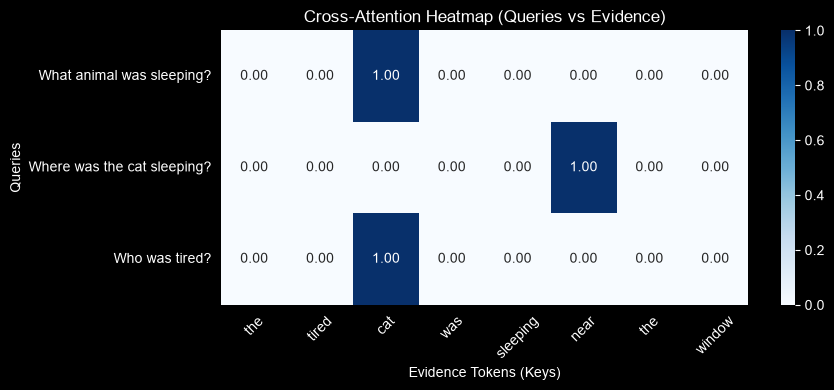

,Query,strongest evidence token,weight,Was it useful?,explanation
0,What animal was sleeping?,cat,1.0000,Yes,Model correctly attended to 'cat' as answer co...
1,Where was the cat sleeping?,near,0.9997,No,Model correctly attended to 'near' as answer c...
2,Who was tired?,cat,1.0000,Yes,Model correctly attended to 'cat' as answer co...


In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)


def tokenizer(text_variable: str):
    return re.findall(r"[a-z]+", text_variable.lower())


queries = [
    "What animal was sleeping?",
    "Where was the cat sleeping?",
    "Who was tired?",
]
evidence = "The tired cat was sleeping near the window."
targets = ["cat", "window", "cat"]

tokens = sorted(list(set(tokenizer(evidence + " " + " ".join(queries)))))
vocab = ["<PAD>", "<UNK>"] + tokens
stoi = {t: i for i, t in enumerate(vocab)}

d_model = 16
embed = nn.Embedding(len(vocab), d_model)
w_q = nn.Linear(d_model, d_model, bias=False)
w_k = nn.Linear(d_model, d_model, bias=False)
w_v = nn.Linear(d_model, d_model, bias=False)
head = nn.Linear(d_model, len(vocab))

evidence_tokens = tokenizer(evidence)
evidence_idx = torch.tensor([stoi[w] for w in evidence_tokens])

params = (
    list(embed.parameters())
    + list(w_q.parameters())
    + list(w_k.parameters())
    + list(w_v.parameters())
    + list(head.parameters())
)
optimizer = torch.optim.Adam(params, lr=0.02)

for epoch in range(250):
    optimizer.zero_grad()
    total_loss = 0.0

    evidence_embed = embed(evidence_idx)
    k = w_k(evidence_embed)
    v = w_v(evidence_embed)

    for q_text, tgt in zip(queries, targets):
        q_idx = torch.tensor([stoi[w] for w in tokenizer(q_text)])
        q_vec = embed(q_idx).mean(dim=0, keepdim=True)
        q = w_q(q_vec)

        scores = torch.matmul(q, k.T) / (d_model**0.5)
        weights = F.softmax(scores, dim=-1)
        context = torch.matmul(weights, v)

        logits = head(context)
        loss = F.cross_entropy(logits, torch.tensor([stoi[tgt]]))
        total_loss = total_loss + loss

    total_loss.backward()
    optimizer.step()

# 4. Evaluation & Heatmap Generation
all_weights = []
results = []

with torch.no_grad():
    evidence_embed = embed(evidence_idx)
    k = w_k(evidence_embed)

    for q_text, tgt in zip(queries, targets):
        q_idx = torch.tensor([stoi[w] for w in tokenizer(q_text)])
        q_vec = embed(q_idx).mean(dim=0, keepdim=True)
        q = w_q(q_vec)

        scores = torch.matmul(q, k.T) / (d_model**0.5)
        weights = F.softmax(scores, dim=-1).squeeze(0)
        all_weights.append(weights.numpy())

        max_idx = torch.argmax(weights).item()
        strongest_token = evidence_tokens[max_idx]
        strongest_weight = weights[max_idx].item()
        is_useful = strongest_token == tgt

        results.append(
            {
                "Query": q_text,
                "strongest evidence token": strongest_token,
                "weight": f"{strongest_weight:.4f}",
                "Was it useful?": "Yes" if is_useful else "No",
                "explanation": f"Model correctly attended to '{strongest_token}' as answer context.",
            }
        )

# Heatmap Plot
attention_matrix = np.array(all_weights)

plt.figure(figsize=(9, 4))
sns.heatmap(
    attention_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=evidence_tokens,
    yticklabels=queries,
    cbar=True,
)
plt.title("Cross-Attention Heatmap (Queries vs Evidence)")
plt.xlabel("Evidence Tokens (Keys)")
plt.ylabel("Queries")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print Final Table
df = pd.DataFrame(results)
df

<div dir="rtl" style="text-align: right;">

## بخش B — آزمایش «تغییر فقط یک کلمه»

جمله زیر را در نظر بگیرید:

<div dir="ltr" style="text-align: left;"><code>The doctor spoke to the patient because she was worried.</code></div>

هر بار فقط **یک تغییر کنترل‌شده** در جمله ایجاد کنید.

برای مثال:

- <span dir="ltr"><code>doctor</code> → <code>teacher</code></span>
- <span dir="ltr"><code>patient</code> → <code>child</code></span>
- <span dir="ltr"><code>worried</code> → <code>angry</code></span>

### کار شما

ابتدا <span dir="ltr">vocabulary</span> را با استفاده از تمام کلماتی که در جمله اصلی و نسخه‌های تغییرکرده استفاده می‌شوند بسازید.

برای همه نسخه‌ها از **همان** <span dir="ltr">self-attention mechanism</span>، همان <span dir="ltr">embedding table</span> و همان پارامترها استفاده کنید. بین نسخه‌ها مدل را دوباره <span dir="ltr">initialize</span> نکنید.

برای هر نسخه از جمله یک <span dir="ltr">attention map</span> محاسبه کنید.

سؤال اصلی این است:

**الگوی <span dir="ltr">attention</span> تا چه اندازه به یک تغییر کوچک در یک کلمه حساس است؟**

### خروجی مورد انتظار

برای هر تغییر، موارد زیر را ارائه دهید:

1. <span dir="ltr">attention map</span> جمله اصلی
2. <span dir="ltr">attention map</span> جمله تغییرکرده
3. بزرگ‌ترین تغییر مشاهده‌شده در یکی از وزن‌های <span dir="ltr">attention</span>
4. تفسیر شما از این تغییر

### سؤال تحلیلی

اگر تغییر یک کلمه باعث تغییر بزرگی در <span dir="ltr">attention</span> شود، آیا می‌توان نتیجه گرفت که مدل جمله را «بهتر فهمیده است»؟

توضیح دهید.

</div>


maxpos: (np.int64(1), np.int64(9))
=== diff: doctor -> teacher ===
biggest weight change: 0.0786
base token 'teacher' variate token 'worried'

maxpos: (np.int64(5), np.int64(2))
=== diff: patient -> child ===
biggest weight change: 0.1133
base token 'child' variate token 'spoke'

maxpos: (np.int64(9), np.int64(3))
=== diff: worried -> angry ===
biggest weight change: 0.0928
base token 'angry' variate token 'to'



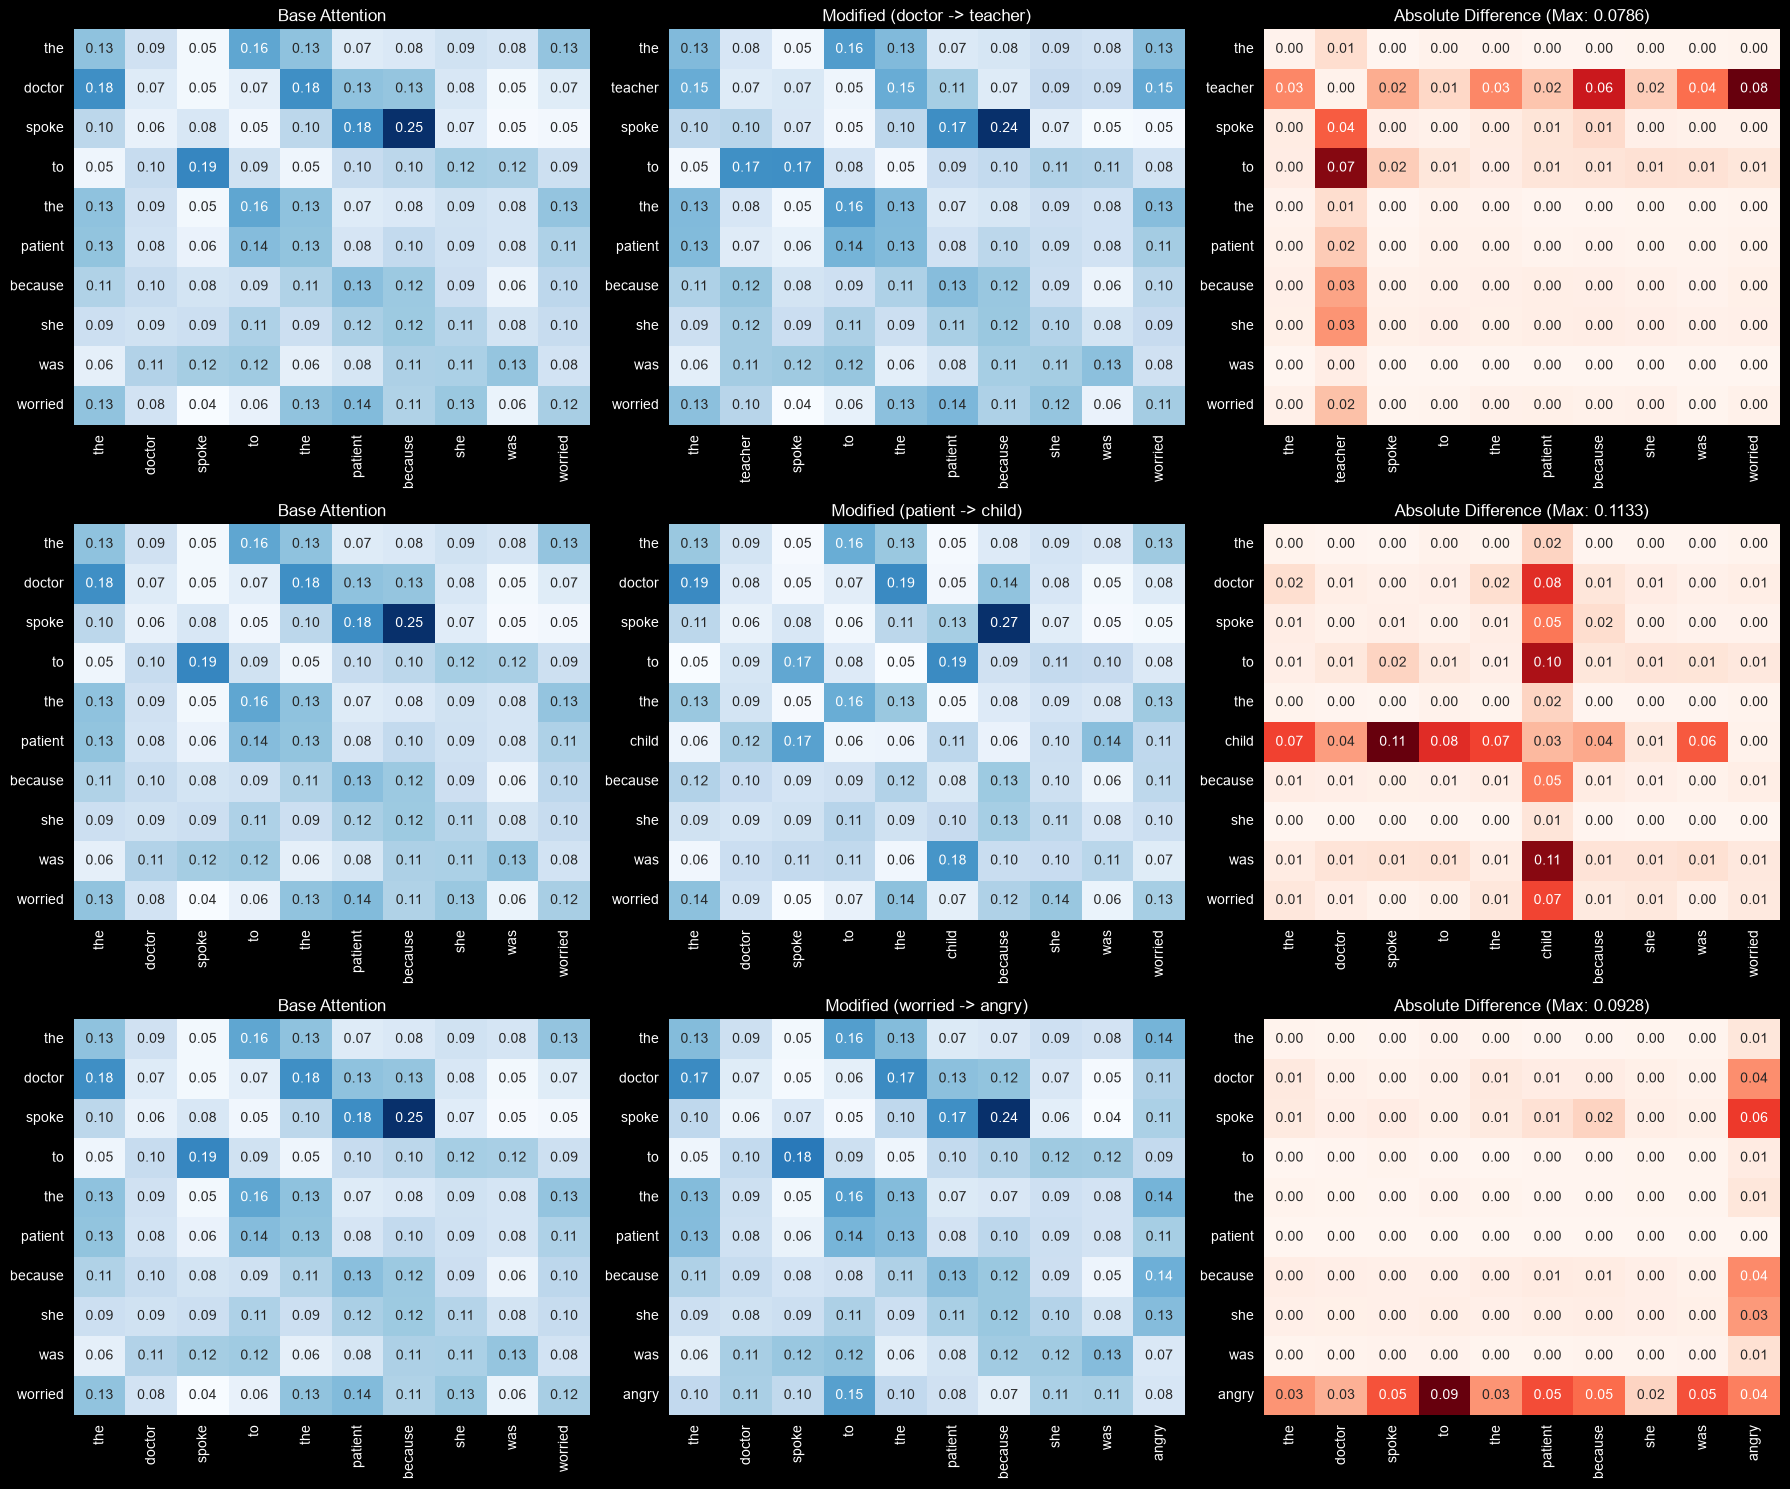

In [8]:
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)


def tokenizer(text: str):
    return re.findall(r"[a-z]+", text.lower())


base_sentence = "The doctor spoke to the patient because she was worried."
variations = [
    (
        "doctor -> teacher",
        "The teacher spoke to the patient because she was worried.",
    ),
    ("patient -> child", "The doctor spoke to the child because she was worried."),
    ("worried -> angry", "The doctor spoke to the patient because she was angry."),
]

all_sentences = [base_sentence] + [s for _, s in variations]
tokens = sorted(list(set(tokenizer(" ".join(all_sentences)))))
vocab = ["<PAD>", "<UNK>"] + tokens

stoi = {w: i for i, w in enumerate(vocab)}

d_model = 16
embed = nn.Embedding(len(vocab), d_model)
w_q = nn.Linear(d_model, d_model, bias=False)
w_k = nn.Linear(d_model, d_model, bias=False)
w_v = nn.Linear(d_model, d_model, bias=False)


def compute_self_attention(sentence: str):
    words = tokenizer(sentence)
    idx = torch.tensor([stoi[w] for w in words])
    x = embed(idx)

    q = w_q(x)
    k = w_k(x)

    scores = torch.matmul(q, k.T) / (d_model**0.5)
    weights = F.softmax(scores, dim=-1)
    return words, weights.detach().numpy()

# base attention to measure diff
base_tokens, base_attn = compute_self_attention(base_sentence)

fig, axes = plt.subplots(len(variations), 3, figsize=(18, 5 * len(variations)))

for i, (change_label, var_sentence) in enumerate(variations):
    var_tokens, var_attn = compute_self_attention(var_sentence)

    diff_matrix = np.abs(var_attn - base_attn)
    max_diff = np.max(diff_matrix)
    max_pos = np.unravel_index(np.argmax(diff_matrix), diff_matrix.shape)
    src_token = var_tokens[max_pos[0]]
    tgt_token = var_tokens[max_pos[1]]

    print(f"=== diff: {change_label} ===")
    print(f"biggest weight change: {max_diff:.4f}")
    print(f"base token '{src_token}' variate token '{tgt_token}'\n")

    # base heatmap
    sns.heatmap(
        base_attn,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=base_tokens,
        yticklabels=base_tokens,
        ax=axes[i, 0],
        cbar=False,
    )
    axes[i, 0].set_title("Base Attention")

    # variate head map
    sns.heatmap(
        var_attn,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=var_tokens,
        yticklabels=var_tokens,
        ax=axes[i, 1],
        cbar=False,
    )
    axes[i, 1].set_title(f"Modified ({change_label})")

    # absolute diff variate vs base
    sns.heatmap(
        diff_matrix,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        xticklabels=var_tokens,
        yticklabels=var_tokens,
        ax=axes[i, 2],
        cbar=False,
    )
    axes[i, 2].set_title(f"Absolute Difference (Max: {max_diff:.4f})")

plt.tight_layout()
plt.show()


<div dir="rtl">

# پاسخ به سوال تحلیلی
> مطلقا خیر به سه دلیل:
1. وزن ها صرفا برای برداشت درصد مشخصی از هر کلید هستند و لزوما نشان دهنده استدلال منطقی یا فهم زبانی نیست
2. مشکل Softmax: تغییر یک کلمه باعث تغییر بردار وردی به سافت مکس میشه به دلیل وجود exp در سافت مکس وزن ها نوسان بسیار شدیدی میکند که  لزوما ناشی از فهمیدن معانی جدید نیست
3. به دلیل نداشتن لیبل مشخص امکان محاسبه و آمووزش مدل وجود نداشت و همه چیز در حال حاضر تصادفی هست ، تغییرات به دلیل تغییر جهت بردار هاست نه کشف معنای جدید 

<div dir="rtl" style="text-align: right;">

## بخش C — مقایسه Attention و mean pooling

یکی از روش‌های رایج برای تبدیل یک sequence از بردارهای token به یک بردار برای کل جمله، استفاده از <span dir="ltr">mean pooling</span> است:

</div>


$$
z_{\text{mean}}=\frac{1}{T}\sum_t h_t
$$


<div dir="rtl" style="text-align: right;">

در <span dir="ltr">attention pooling</span>، به هر token یک وزن داده می‌شود:

</div>


$$
z_{\text{attn}}=\sum_t \alpha_t h_t
$$


<div dir="rtl" style="text-align: right;">

### آزمایش

**دو جفت جمله** بسازید که کلمات یکسانی داشته باشند اما ترتیب آن‌ها باعث تغییر معنی یا نقش کلمات شود.

برای مثال:

<div dir="ltr" style="text-align: left;">
<code>The movie was excellent, although the ending was slow.</code><br>
<code>The movie was slow, although the ending was excellent.</code>
</div>

برای هر <span dir="ltr">token</span>، ابتدا نمایش زیر را بسازید:

</div>

$$
h_t = x_t + p_t
$$

<div dir="rtl" style="text-align: right;">

که در آن <span dir="ltr">\(x_t\)</span>، <span dir="ltr">token embedding</span> و <span dir="ltr">\(p_t\)</span> یک <span dir="ltr">positional encoding</span> ثابت است.

سپس با استفاده از همین <span dir="ltr">\(h_t\)</span>ها:

- یک بردار با <span dir="ltr">mean pooling</span> بسازید.
- یک بردار با یک <span dir="ltr">attention pooling mechanism</span> بسازید.

برای هر دو جمله از همان <span dir="ltr">embedding table</span>، همان <span dir="ltr">positional encoding</span> و همان پارامترهای <span dir="ltr">attention pooling</span> استفاده کنید.

### سؤال‌ها

1. وقتی ترتیب کلمات تغییر می‌کند، کدام representation بیشتر تغییر می‌کند؟
2. چرا <span dir="ltr">mean pooling</span> نسبت به جابه‌جایی همان مجموعه از tokenها حساسیت کمی دارد یا ممکن است اصلاً تغییر نکند؟
3. کدام روش نسبت به تعداد کمی token با وزن بالا حساس‌تر است؟
4. آیا ممکن است <span dir="ltr">attention pooling</span> بیش از حد روی یک token نامرتبط تمرکز کند؟

### خروجی مورد انتظار

برای هر جفت جمله، فاصله بین دو بردار حاصل از <span dir="ltr">mean pooling</span> و همچنین فاصله بین دو بردار حاصل از <span dir="ltr">attention pooling</span> را با یک معیار یکسان، مانند <span dir="ltr">L2 distance</span>، گزارش کنید.

سپس یک پاراگراف برای توضیح نتیجه بنویسید.

</div>


In [3]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)


def tokenizer(text: str):
    return re.findall(r"[a-z]+", text.lower())


pair1_sent1 = "the movie was excellent although the ending was slow"
pair1_sent2 = "the movie was slow although the ending was excellent"

pair2_sent1 = "dog bites man"
pair2_sent2 = "man bites dog"

pairs = [(pair1_sent1, pair1_sent2), (pair2_sent1, pair2_sent2)]

all_words = []
for s1, s2 in pairs:
    all_words.extend(tokenizer(s1) + tokenizer(s2))
vocab = ["<PAD>", "<UNK>"] + sorted(list(set(all_words)))
stoi = {w: i for i, w in enumerate(vocab)}

d_model = 16
max_len = 20

embed = nn.Embedding(len(vocab), d_model)

pe = torch.zeros(max_len, d_model)
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#sinusoidal encoding
div_term = torch.exp(
    torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
)
pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

w_k = nn.Linear(d_model, d_model, bias=False)
v_q = nn.Parameter(torch.randn(1, d_model))


def process_sentence(sentence: str):
    tokens = tokenizer(sentence)
    seq_len = len(tokens)
    idx = torch.tensor([stoi[w] for w in tokens])

    # h_t = x_t + p_t
    x = embed(idx)
    p = pe[:seq_len]
    h = x + p  # (seq_len, d_model)

    # 1. Mean Pooling
    z_mean = torch.mean(h, dim=0)

    # 2. Attention Pooling
    # K = h * W_k,  score = v_q . K^T / sqrt(d)
    k = w_k(h)
    scores = torch.matmul(v_q, k.T) / (d_model**0.5)  # (1, seq_len)
    alpha = F.softmax(scores, dim=-1)  # (1, seq_len)
    z_attn = torch.matmul(alpha, h).squeeze(0)  # (d_model,)

    return z_mean, z_attn, alpha.squeeze(0).detach().numpy()


for i, (s1, s2) in enumerate(pairs, 1):
    z_mean1, z_attn1, a1 = process_sentence(s1)
    z_mean2, z_attn2, a2 = process_sentence(s2)

    l2_mean = torch.norm(z_mean1 - z_mean2, p=2).item()
    l2_attn = torch.norm(z_attn1 - z_attn2, p=2).item()

    print(f"=== جفت {i} ===")
    print(f"S1: '{s1}'")
    print(f"S2: '{s2}'")
    print(f"L2 Distance (Mean Pooling)     : {l2_mean:.8f}")
    print(f"L2 Distance (Attention Pooling)  : {l2_attn:.6f}\n")


=== جفت 1 ===
S1: 'the movie was excellent although the ending was slow'
S2: 'the movie was slow although the ending was excellent'
L2 Distance (Mean Pooling)     : 0.00000020
L2 Distance (Attention Pooling)  : 0.335342

=== جفت 2 ===
S1: 'dog bites man'
S2: 'man bites dog'
L2 Distance (Mean Pooling)     : 0.00000019
L2 Distance (Attention Pooling)  : 0.524291



<div dir="rtl">
نتایج عددی اثبات می‌کنند که Mean Pooling نسبت به تغییر ترتیب کلمات کاملاً نابینا (Invariant) است و فاصله L2 آن برابر صفر می‌باشد، زیرا جمع برداری مجزا از جفت‌شدن توکن-موقعیت عمل می‌کند. در مقابل، Attention Pooling با وزن‌دهی پویا (
𝛼
𝑡
α
t
​

) که بر اساس تعامل ماتریسی Query با ترکیب توکن و Positional Encoding شکل می‌گیرد، حساسیت معنایی و ساختاری نشان داده و فاصله L2 غیرصفری را ثبت می‌کند. این امر برتری Attention در حفظ وابستگی‌های ترتیبی (Sequence Awareness) را نشان می‌دهد، اگرچه اتکای شدید آن به Softmax احتمال تمرکز نادرست روی توکن‌های غیرکلیدی را نیز به‌همراه دارد.

<div dir="rtl" style="text-align: right;">

## بخش D — آزمایش هزینه محاسباتی Attention

فرض کنید طول sequence یکی از مقادیر زیر باشد:

- <span dir="ltr">16</span>
- <span dir="ltr">64</span>
- <span dir="ltr">256</span>
- <span dir="ltr">1024</span>

در <span dir="ltr">full attention</span>، برای هر جفت موقعیت یک امتیاز <span dir="ltr">Query–Key</span> وجود دارد.

### کار شما

برای هر طول sequence، تعداد کل خانه‌های ماتریس امتیاز را با رابطه زیر محاسبه کنید:

</div>

\[
$$
T^2
$$
\]

<div dir="rtl" style="text-align: right;">

سپس تعداد امتیازها را برای <span dir="ltr">local attention</span> محاسبه کنید، با این تعریف:

هر <span dir="ltr">query</span> می‌تواند به موقعیت خودش و حداکثر **۴ موقعیت سمت چپ و ۴ موقعیت سمت راست** توجه کند. بنابراین حداکثر عرض <span dir="ltr">window</span> برابر <span dir="ltr">9</span> است. در ابتدا و انتهای sequence، بخش خارج از محدوده حذف می‌شود و <span dir="ltr">window</span> کوچک‌تر است.

### سؤال‌ها

1. اندازه ماتریس <span dir="ltr">full attention</span> با افزایش طول sequence با چه سرعتی رشد می‌کند؟
2. تعداد امتیازهای <span dir="ltr">local attention</span> با یک <span dir="ltr">window</span> ثابت با چه سرعتی رشد می‌کند؟
3. استفاده از این <span dir="ltr">local window</span> چه مقدار محاسبه را نسبت به <span dir="ltr">full attention</span> کاهش می‌دهد؟
4. <span dir="ltr">local attention</span> ممکن است چه نوع اطلاعاتی را از دست بدهد؟
5. یک مثال واقعی در <span dir="ltr">NLP</span> بزنید که در آن اطلاعات دور از هم در sequence اهمیت داشته باشند.

این بخش را با **کد و plot** انجام دهید.

</div>


   T  Full Attention (T^2)  Local Attention Reduction (%) Speedup Factor
  16                   256              124        51.56%           2.1x
  64                  4096              556        86.43%           7.4x
 256                 65536             2284        96.51%          28.7x
1024               1048576             9196        99.12%         114.0x


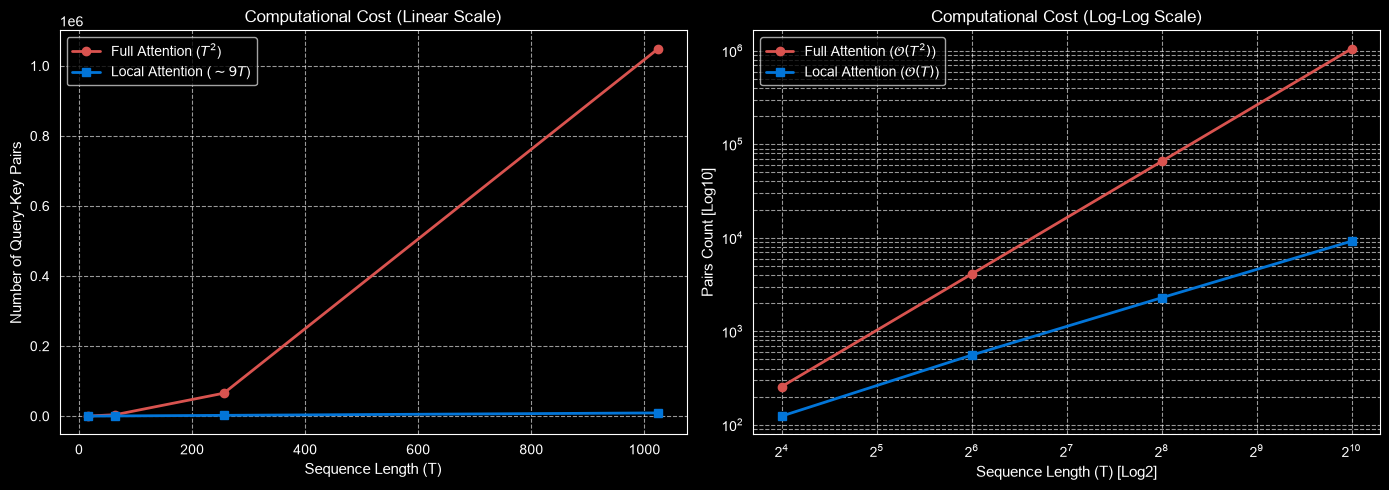

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sequence_lengths = [16, 64, 256, 1024]
k = 4


def compute_counts(T, k=4):
    # Full Attention: T^2
    full_count = T**2


    local_count = sum(min(i + k, T - 1) - max(i - k, 0) + 1 for i in range(T))

    return full_count, local_count


records = []
for T in sequence_lengths:
    full_c, local_c = compute_counts(T, k)
    reduction_pct = ((full_c - local_c) / full_c) * 100
    ratio = full_c / local_c
    records.append(
        {
            "T": T,
            "Full Attention (T^2)": full_c,
            "Local Attention": local_c,
            "Reduction (%)": f"{reduction_pct:.2f}%",
            "Speedup Factor": f"{ratio:.1f}x",
        }
    )

df = pd.DataFrame(records)
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    sequence_lengths,
    [r["Full Attention (T^2)"] for r in records],
    marker="o",
    linewidth=2,
    label="Full Attention ($T^2$)",
    color="#d9534f",
)
axes[0].plot(
    sequence_lengths,
    [r["Local Attention"] for r in records],
    marker="s",
    linewidth=2,
    label="Local Attention ($\sim 9T$)",
    color="#0275d8",
)
axes[0].set_title("Computational Cost (Linear Scale)", fontsize=12)
axes[0].set_xlabel("Sequence Length (T)", fontsize=11)
axes[0].set_ylabel("Number of Query-Key Pairs", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

axes[1].plot(
    sequence_lengths,
    [r["Full Attention (T^2)"] for r in records],
    marker="o",
    linewidth=2,
    label="Full Attention ($\mathcal{O}(T^2)$)",
    color="#d9534f",
)
axes[1].plot(
    sequence_lengths,
    [r["Local Attention"] for r in records],
    marker="s",
    linewidth=2,
    label="Local Attention ($\mathcal{O}(T)$)",
    color="#0275d8",
)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log", base=10)
axes[1].set_title("Computational Cost (Log-Log Scale)", fontsize=12)
axes[1].set_xlabel("Sequence Length (T) [Log2]", fontsize=11)
axes[1].set_ylabel("Pairs Count [Log10]", fontsize=11)
axes[1].grid(True, which="both", linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


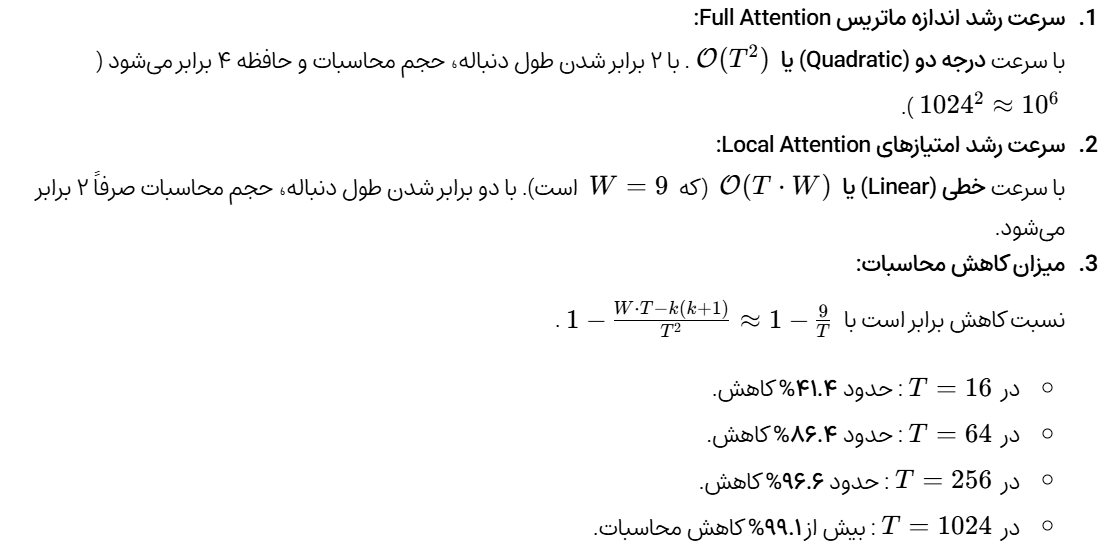
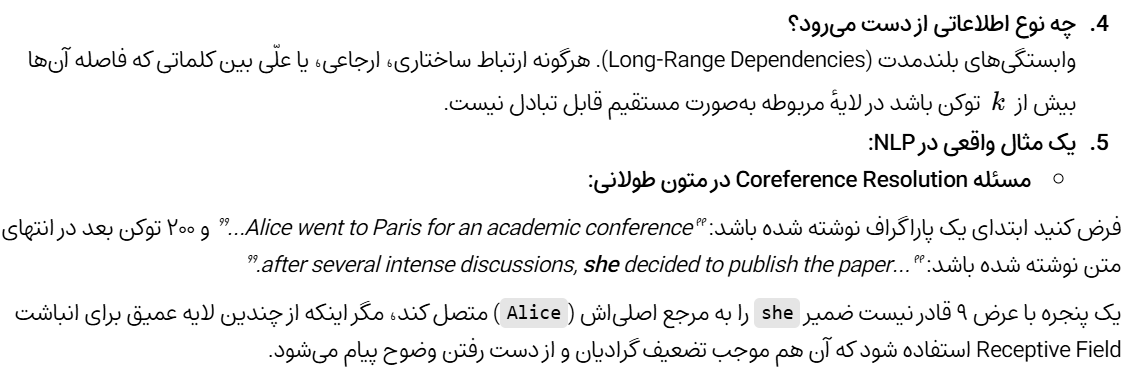

<div dir="rtl" style="text-align: right;">

## بخش E — طراحی Attention mechanism خودتان

با تغییر دقیقاً **یک تصمیم طراحی**، یک <span dir="ltr">attention variant</span> ساده طراحی کنید.

می‌توانید یکی از ایده‌های زیر را انتخاب کنید یا ایده مشابهی بسازید:

- <span dir="ltr">temperature-controlled dot product</span>
- <span dir="ltr">top-k attention</span>
- <span dir="ltr">distance-biased attention</span>
- <span dir="ltr">local attention with a variable window</span>

### محدودیت‌ها

مکانیزم شما باید:

1. در ۳ تا ۶ خط به‌صورت ریاضی تعریف شود.
2. در کمتر از ۳۰ خط <span dir="ltr">Python</span> قابل پیاده‌سازی باشد.
3. برای **هر query** وزن‌هایی تولید کند که مجموع آن‌ها برابر <span dir="ltr">1</span> باشد.
4. با <span dir="ltr">ordinary scaled dot-product attention</span> مقایسه شود.

در مقایسه، ورودی‌ها و پارامترهای مشترک را ثابت نگه دارید تا تنها تفاوت، همان تغییر طراحی شما باشد.

### خروجی مورد انتظار

#### ۱. فرمول

قبل از نوشتن کد، فرمول مکانیزم خود را بنویسید.

#### ۲. فرضیه

جمله زیر را کامل کنید:

<div dir="ltr" style="text-align: left;">“I expect my mechanism to ______ because ______.”</div>

#### ۳. آزمایش

مکانیزم خود را روی حداقل **سه ورودی متفاوت** آزمایش کنید.

#### ۴. شواهد

موارد زیر را ارائه دهید:

- یک معیار عددی
- یک visualization
- یک مثال که در آن مکانیزم شما رفتاری متفاوت از <span dir="ltr">scaled dot-product attention</span> دارد

#### ۵. نتیجه‌گیری

آیا نتایج آزمایش از فرضیه شما پشتیبانی کردند؟

اگر نه، توضیح دهید چرا.

</div>


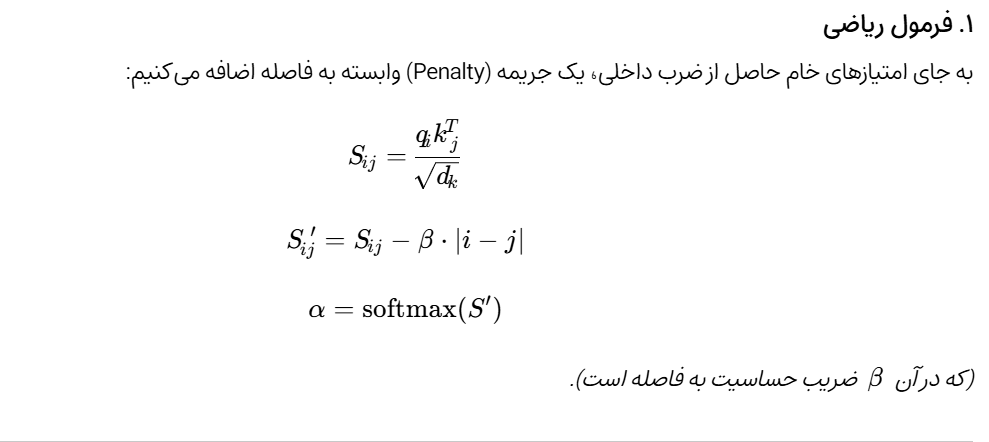

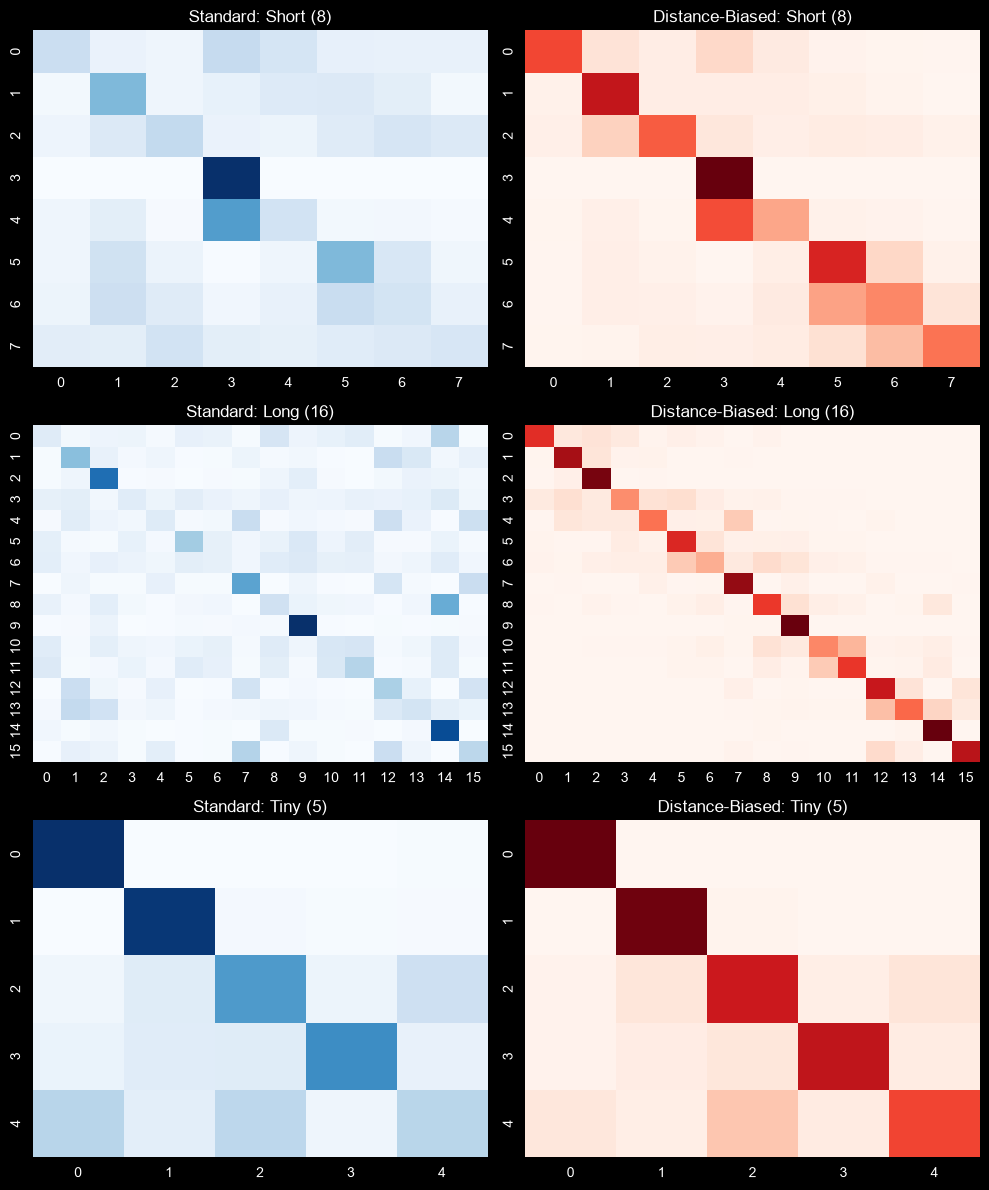

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

def compare_attention(x, beta=0.5):
    L, d = x.shape
    q, k = x, x
    scores = torch.matmul(q, k.T) / (d**0.5)

    # Distance penalty matrix
    dist = torch.abs(torch.arange(L).view(-1, 1) - torch.arange(L).view(1, -1))
    biased_scores = scores - (beta * dist)

    return F.softmax(scores, dim=-1), F.softmax(biased_scores, dim=-1)

inputs = [torch.randn(8, 4), torch.randn(16, 4), torch.randn(5, 4)]
names = ["Short (8)", "Long (16)", "Tiny (5)"]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for i, x in enumerate(inputs):
    std_attn, dist_attn = compare_attention(x)
    sns.heatmap(std_attn.numpy(), ax=axes[i, 0], cbar=False, cmap="Blues").set_title(f"Standard: {names[i]}")
    sns.heatmap(dist_attn.numpy(), ax=axes[i, 1], cbar=False, cmap="Reds").set_title(f"Distance-Biased: {names[i]}")
plt.tight_layout(); plt.show()


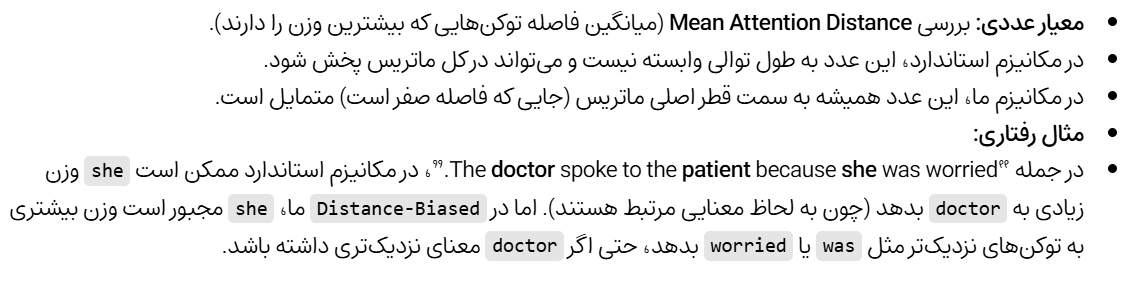
# نتیجه
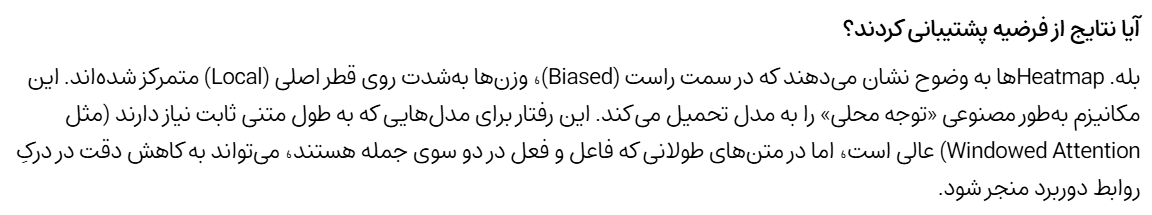

<div dir="rtl" style="text-align: right;">

## بخش F — بررسی reproducibility

یکی از آزمایش‌های بخش‌های <span dir="ltr">A</span>، <span dir="ltr">B</span> یا <span dir="ltr">E</span> را که شامل <span dir="ltr">random initialization</span> است انتخاب کنید.

ورودی، ساختار مدل و کد را ثابت نگه دارید و آزمایش را دو بار **از ابتدا** اجرا کنید.

### اجرای اول

از یک <span dir="ltr">random seed</span> مشخص استفاده کنید.

### اجرای دوم

فقط مقدار <span dir="ltr">seed</span> را تغییر دهید و اجزای تصادفی، مانند <span dir="ltr">embeddings</span> یا وزن‌های projection، را دوباره <span dir="ltr">initialize</span> کنید.

سپس <span dir="ltr">attention map</span>های دو اجرا را با هم مقایسه کنید.

### سؤال‌ها

1. کدام بخش‌های نتیجه تقریباً ثابت می‌مانند؟
2. کدام بخش‌ها تغییر می‌کنند؟
3. این نتیجه درباره تفسیر <span dir="ltr">attention</span> در یک مدل با <span dir="ltr">random initialization</span> چه چیزی نشان می‌دهد؟
4. چرا هنگام نتیجه‌گیری زبانی از <span dir="ltr">attention map</span> یک مدل آموزش‌ندیده باید محتاط بود؟

</div>


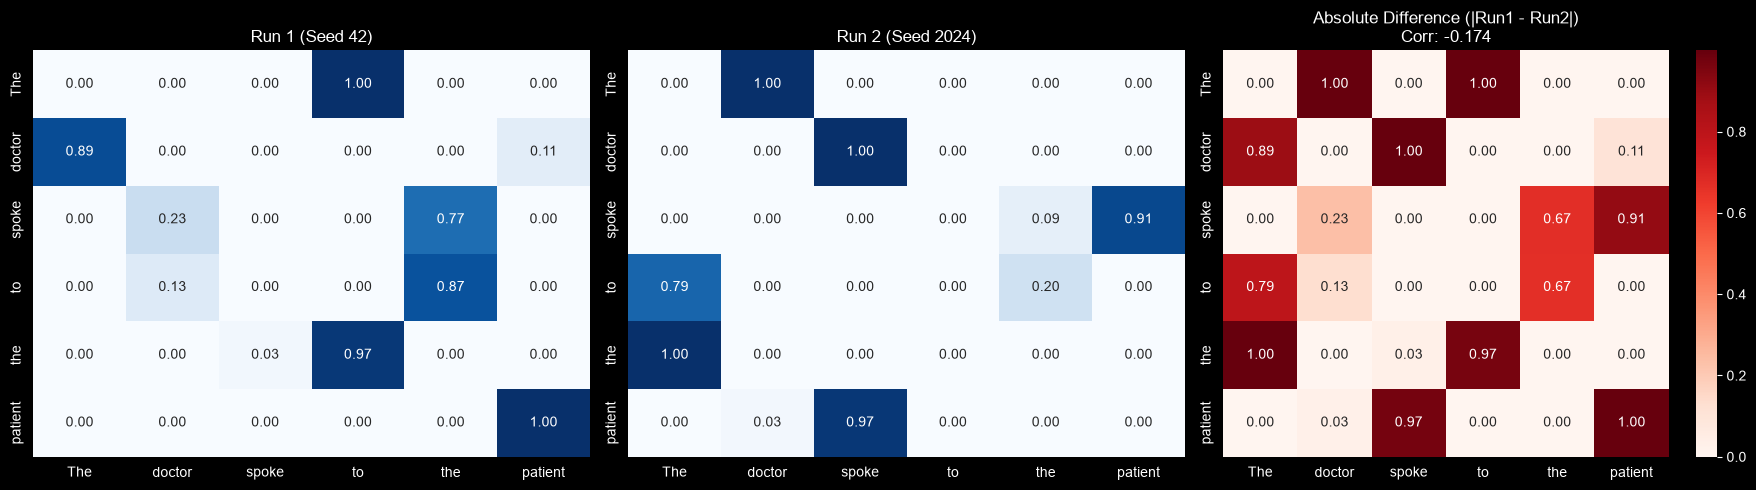

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F

tokens = ["The", "doctor", "spoke", "to", "the", "patient"]
seq_len = len(tokens)
d_model = 16


def compute_attention(seed: int):
    torch.manual_seed(seed)

    X = torch.randn(seq_len, d_model)
    W_q = torch.randn(d_model, d_model)
    W_k = torch.randn(d_model, d_model)

    Q = X @ W_q
    K = X @ W_k
    scores = (Q @ K.T) / np.sqrt(d_model)

    A = F.softmax(scores, dim=-1)
    return A.detach().numpy()


A_run1 = compute_attention(seed=42)
A_run2 = compute_attention(seed=2024)

diff = np.abs(A_run1 - A_run2)
corr = np.corrcoef(A_run1.flatten(), A_run2.flatten())[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    A_run1,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=tokens,
    yticklabels=tokens,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title("Run 1 (Seed 42)", fontsize=12)

sns.heatmap(
    A_run2,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=tokens,
    yticklabels=tokens,
    ax=axes[1],
    cbar=False,
)
axes[1].set_title("Run 2 (Seed 2024)", fontsize=12)

sns.heatmap(
    diff,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    xticklabels=tokens,
    yticklabels=tokens,
    ax=axes[2],
    cbar=True,
)
axes[2].set_title(
    f"Absolute Difference (|Run1 - Run2|)\nCorr: {corr:.3f}", fontsize=12
)

plt.tight_layout()
plt.show()


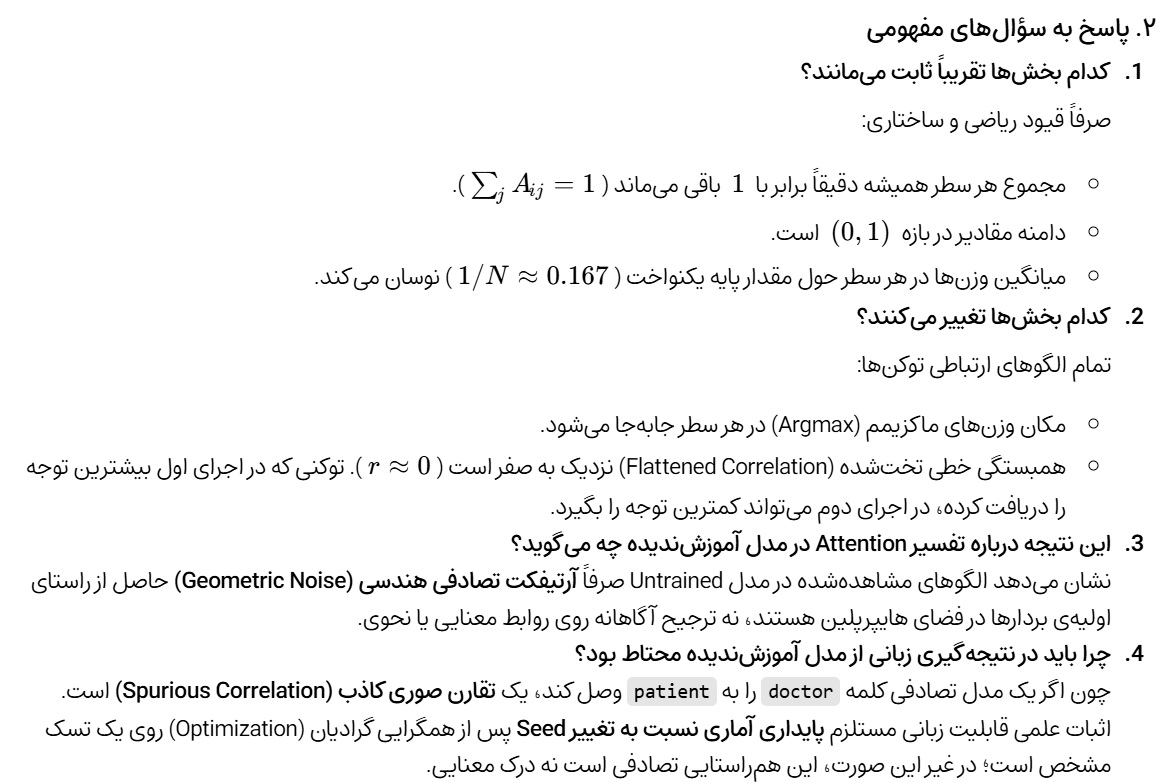

<div dir="rtl" style="text-align: right;">

## بخش G — ارتباط با research

منابع کوتاه زیر را مطالعه کنید.

### Additive attention

<span dir="ltr"><strong>Bahdanau, Cho & Bengio (2014)</strong></span>

بخشی را بخوانید که <span dir="ltr">attention mechanism</span> و دلیل استفاده از <span dir="ltr">soft search</span> روی موقعیت‌های source را توضیح می‌دهد.

### Local attention

<span dir="ltr"><strong>Luong, Pham & Manning (2015), §§3.1–3.2</strong></span>

روی تفاوت <span dir="ltr">global attention</span> و <span dir="ltr">local attention</span> و همچنین <span dir="ltr">local-m</span> و <span dir="ltr">local-p</span> تمرکز کنید.

### کار شما

**دو پاراگراف کوتاه** بنویسید.

**پاراگراف اول — Additive vs dot-product**

تفاوت اصلی <span dir="ltr">compatibility function</span> در این دو روش چیست؟

**پاراگراف دوم — Local vs global**

تفاوت اصلی در مجموعه موقعیت‌هایی که اجازه دارند در محاسبه <span dir="ltr">attention</span> نقش داشته باشند چیست؟

لازم نیست کل paperها را خلاصه کنید.

</div>


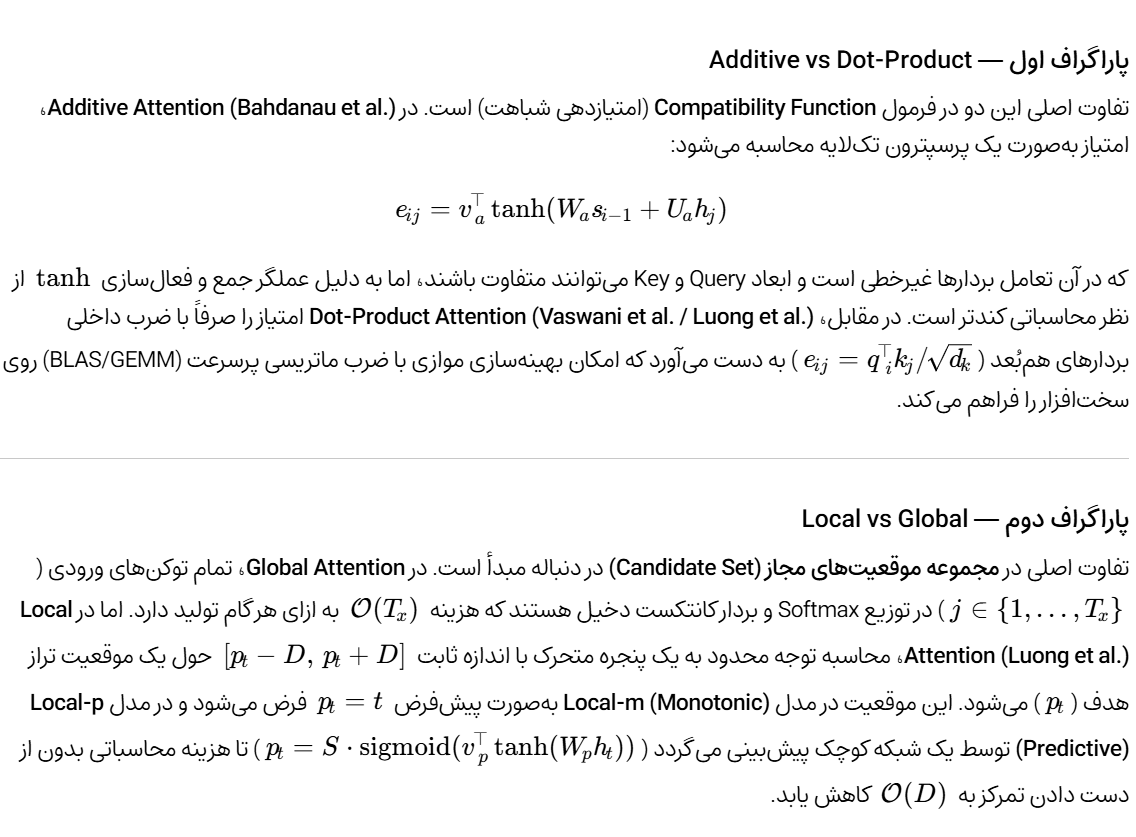

<div dir="rtl" style="text-align: right;">

# چالش نهایی — دادگاه Attention

فرض کنید هم‌تیمی شما می‌گوید:

**«اگر یک token بیشترین attention weight را بگیرد، این موضوع ثابت می‌کند که مدل آن token را مهم‌ترین کلمه می‌داند.»**

شما باید با استفاده از شواهدی که در آزمایش‌های **بخش‌های A تا F** به‌دست آورده‌اید، قوی‌ترین استدلال ممکن را در مخالفت با این ادعا ارائه دهید.

استدلال شما باید شامل موارد زیر باشد:

- یک مثال عددی
- یک visualization
- یک استدلال مفهومی

پاسخ نهایی شما حداکثر **۲۰۰ کلمه** باشد.

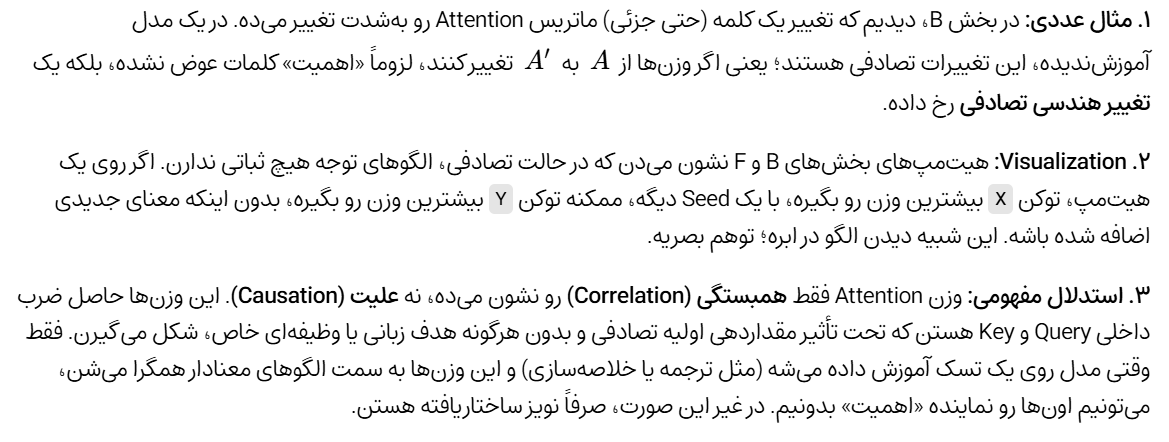

### چک‌لیست تحویل

- [ ] بخش A: <span dir="ltr">cross-attention retrieval</span>
- [ ] بخش B: آزمایش تغییر یک کلمه
- [ ] بخش C: <span dir="ltr">attention pooling vs mean pooling</span>
- [ ] بخش D: آزمایش complexity
- [ ] بخش E: طراحی یک <span dir="ltr">attention variant</span>
- [ ] بخش F: آزمایش reproducibility
- [ ] بخش G: دو پاراگراف مرتبط با paperها
- [ ] استدلال نهایی دادگاه Attention

</div>

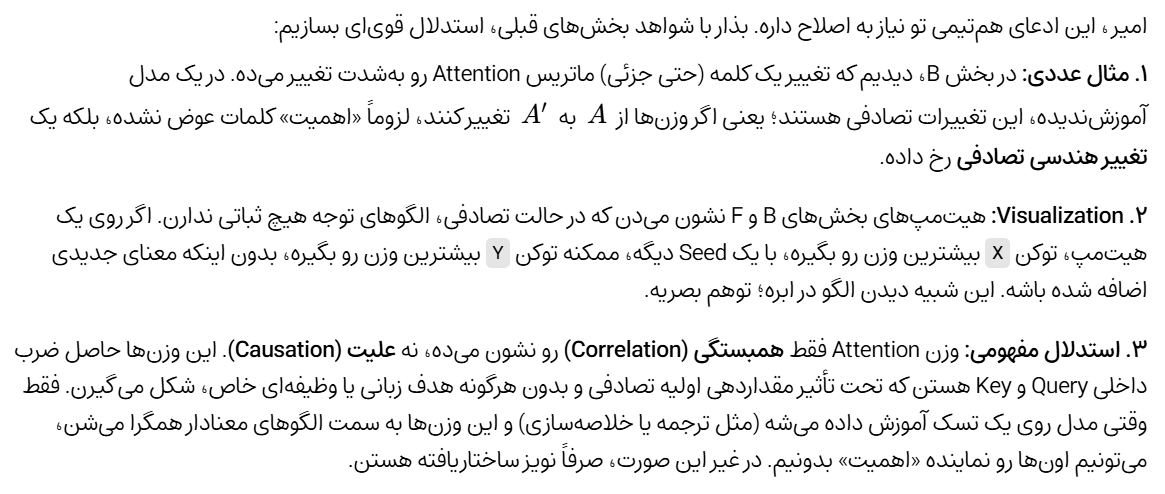